# Polymer Informatics Atlas

## Notebook 04 — Chemistry-Aware Generalization

### Scientific objective

Notebook 03 established property-specific predictive baselines using a conventional random train/holdout split.

Random splitting, however, does not guarantee that holdout polymers are chemically distinct from the polymers available during model training.

A model may therefore achieve strong random-split performance primarily by interpolating among structurally similar polymers.

Notebook 04 evaluates predictive generalization as a function of chemical novelty.

The central question is:

> **How does prediction reliability change as a holdout polymer becomes chemically less similar to the training chemistry?**

Chemical similarity is quantified using Tanimoto similarity over binary structural features derived from the frozen radius-4 Morgan representation developed in Notebook 02.

For every holdout polymer, we measure its relationship to the corresponding training set using:

- maximum training-set similarity;
- mean similarity to its five nearest training neighbours;
- number of close training neighbours above selected similarity thresholds.

These quantities provide a direct measure of whether a prediction represents:

- local interpolation;
- moderate structural generalization;
- or extrapolation toward chemically sparse regions.

### Methodological constraint

Notebook 04 does **not** use chemistry-aware performance to retune or replace the models selected in Notebook 03.

The models, representations, hyperparameters, train/test partitions, and holdout predictions remain frozen.

The purpose of this notebook is evaluation of generalization, not further optimization.

In [9]:
# Install required chemistry toolkit
%pip install -q rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.1/38.1 MB 38.2 MB/s eta 0:00:00


In [2]:
# ============================================================
# Upload frozen Notebook 02 and Notebook 03 artifacts
# ============================================================

from google.colab import files

uploaded = files.upload()

Saving polymer_atlas_notebook02_outputs.zip to polymer_atlas_notebook02_outputs.zip
Saving polymer_atlas_notebook03_outputs.zip to polymer_atlas_notebook03_outputs (1).zip


In [3]:
# ============================================================
# Extract frozen project artifacts
# ============================================================

from pathlib import Path
import zipfile
import json
import numpy as np
import pandas as pd

BASE_DIR = Path("/content")

nb02_zip = (
    BASE_DIR
    / "polymer_atlas_notebook02_outputs.zip"
)

nb03_zip = (
    BASE_DIR
    / "polymer_atlas_notebook03_outputs.zip"
)

NB02_DIR = (
    BASE_DIR
    / "polymer_atlas_notebook02_outputs"
)

NB03_DIR = (
    BASE_DIR
    / "polymer_atlas_notebook03_outputs"
)

NB02_DIR.mkdir(
    exist_ok=True
)

NB03_DIR.mkdir(
    exist_ok=True
)


with zipfile.ZipFile(
    nb02_zip,
    "r"
) as z:

    z.extractall(
        NB02_DIR
    )


with zipfile.ZipFile(
    nb03_zip,
    "r"
) as z:

    z.extractall(
        NB03_DIR
    )


print("Notebook 02 artifacts extracted.")
print("Notebook 03 artifacts extracted.")

Notebook 02 artifacts extracted.
Notebook 03 artifacts extracted.


In [4]:
# ============================================================
# Load Notebook 02 representations
# ============================================================

X_interpretable = np.load(
    NB02_DIR
    / "X_interpretable.npy"
)

X_morgan = np.load(
    NB02_DIR
    / "X_morgan_count_r4.npy"
)

X_hybrid = np.load(
    NB02_DIR
    / "X_hybrid.npy"
)

metadata = pd.read_csv(
    NB02_DIR
    / "polymer_model_metadata.csv"
)


print("NOTEBOOK 02 INPUTS")
print("=" * 70)

print(
    "Metadata:       ",
    metadata.shape
)

print(
    "Interpretable:  ",
    X_interpretable.shape
)

print(
    "Morgan r4:      ",
    X_morgan.shape
)

print(
    "Hybrid:         ",
    X_hybrid.shape
)

NOTEBOOK 02 INPUTS
Metadata:        (7973, 8)
Interpretable:   (7973, 36)
Morgan r4:       (7973, 2048)
Hybrid:          (7973, 2084)


In [5]:
# ============================================================
# Load Notebook 03 frozen evaluation artifacts
# ============================================================

frozen_splits = pd.read_csv(
    NB03_DIR
    / "frozen_target_splits.csv"
)

final_holdout_results = pd.read_csv(
    NB03_DIR
    / "final_holdout_results.csv"
)

with open(
    NB03_DIR
    / "notebook03_model_config.json",
    "r"
) as f:

    notebook03_config = json.load(f)


target_columns = [
    "Tg",
    "FFV",
    "Tc",
    "Density",
    "Rg"
]


holdout_predictions = {}

for target in target_columns:

    holdout_predictions[target] = (
        pd.read_csv(
            NB03_DIR
            / f"{target}_holdout_predictions.csv"
        )
    )


print("\nNOTEBOOK 03 INPUTS")
print("=" * 70)

print(
    "Frozen split rows:      ",
    frozen_splits.shape
)

print(
    "Final holdout results:  ",
    final_holdout_results.shape
)

for target in target_columns:

    print(
        f"{target:8s}: "
        f"{len(holdout_predictions[target])} "
        f"holdout predictions"
    )


NOTEBOOK 03 INPUTS
Frozen split rows:       (9505, 3)
Final holdout results:   (5, 8)
Tg      : 103 holdout predictions
FFV     : 1406 holdout predictions
Tc      : 148 holdout predictions
Density : 123 holdout predictions
Rg      : 123 holdout predictions


## 4. Integrity Audit

Before calculating chemical novelty, the frozen artifacts from Notebooks 02 and 03 are checked for alignment.

Notebook 04 must preserve exactly the same:

- polymer ordering;
- target-specific training partitions;
- target-specific holdout partitions;
- final Notebook 03 predictions.

Any mismatch would invalidate the chemistry-aware comparison.

In [6]:
# ============================================================
# Integrity checks
# ============================================================

n_polymers = len(metadata)

assert (
    X_interpretable.shape[0]
    == n_polymers
)

assert (
    X_morgan.shape[0]
    == n_polymers
)

assert (
    X_hybrid.shape[0]
    == n_polymers
)

assert metadata["id"].is_unique


for target in target_columns:

    split_target = frozen_splits[
        frozen_splits["Target"]
        == target
    ]

    train_rows = split_target[
        split_target["Partition"]
        == "train"
    ]

    test_rows = split_target[
        split_target["Partition"]
        == "test"
    ]

    prediction_rows = (
        holdout_predictions[target]
    )

    assert (
        len(test_rows)
        == len(prediction_rows)
    )

    assert (
        set(test_rows["row_index"])
        ==
        set(prediction_rows["row_index"])
    )


print("NOTEBOOK 04 ENTRY AUDIT")
print("=" * 70)

print(
    f"Polymers aligned:       {n_polymers:,}"
)

print(
    "Morgan features:       ",
    X_morgan.shape[1]
)

print(
    "Targets checked:       ",
    len(target_columns)
)

print(
    "Frozen split alignment: PASSED"
)

print(
    "Holdout alignment:      PASSED"
)

NOTEBOOK 04 ENTRY AUDIT
Polymers aligned:       7,973
Morgan features:        2048
Targets checked:        5
Frozen split alignment: PASSED
Holdout alignment:      PASSED


## 5. Chemical-Similarity Representation

The predictive Morgan representation stores **counts** of radius-4 structural environments.

For chemical-neighbourhood analysis, these counts are converted to binary presence/absence features:

$$
b_j =
\begin{cases}
1, & x_j > 0 \\
0, & x_j = 0
\end{cases}
$$

This allows conventional Tanimoto similarity to be calculated between polymer repeat-unit fingerprints.

For binary fingerprints $A$ and $B$:

$$
T(A,B)
=
\frac{|A \cap B|}
{|A| + |B| - |A \cap B|}
$$

where:

- $T = 1$ indicates identical fingerprint feature sets;
- $T = 0$ indicates no shared active fingerprint features.

The binary fingerprint is used only to define chemical neighbourhoods.

The predictive models themselves remain exactly those frozen in Notebook 03.

In [7]:
# ============================================================
# Binary radius-4 fingerprint representation
# ============================================================

X_morgan_binary = (
    X_morgan > 0
).astype(np.uint8)

active_features = (
    X_morgan_binary.sum(
        axis=1
    )
)

print("CHEMICAL-SIMILARITY REPRESENTATION")
print("=" * 70)

print(
    "Shape:                ",
    X_morgan_binary.shape
)

print(
    "Binary values:        ",
    np.unique(
        X_morgan_binary
    )
)

print(
    "Mean active features: ",
    active_features.mean()
)

print(
    "Median active features:",
    np.median(
        active_features
    )
)

print(
    "Minimum:              ",
    active_features.min()
)

print(
    "Maximum:              ",
    active_features.max()
)

CHEMICAL-SIMILARITY REPRESENTATION
Shape:                 (7973, 2048)
Binary values:         [0 1]
Mean active features:  67.39144613069108
Median active features: 65.0
Minimum:               4
Maximum:               231


In [10]:
# ============================================================
# Build RDKit bit vectors for fast Tanimoto calculations
# ============================================================

from rdkit import DataStructs

n_bits = (
    X_morgan_binary.shape[1]
)

rdkit_fingerprints = []

for row in X_morgan_binary:

    bv = DataStructs.ExplicitBitVect(
        n_bits
    )

    on_bits = np.flatnonzero(
        row
    )

    for bit in on_bits:
        bv.SetBit(
            int(bit)
        )

    rdkit_fingerprints.append(
        bv
    )


print(
    f"RDKit fingerprints created: "
    f"{len(rdkit_fingerprints):,}"
)

print(
    f"Bits per fingerprint: {n_bits}"
)

RDKit fingerprints created: 7,973
Bits per fingerprint: 2048


## 7. Training-Neighbourhood Similarity

For each holdout polymer, similarity is calculated only against polymers belonging to the corresponding target-specific training partition.

The primary novelty measure is:

$$
S_{\max}(i)
=
\max_{j \in \mathcal{T}}
T(i,j)
$$

where $\mathcal{T}$ is the training set.

A high value of $S_{\max}$ indicates that the holdout polymer has a close structural analogue available during training.

A low value indicates increasing chemical novelty.

Additional neighbourhood descriptors include:

- mean similarity of the five closest training polymers;
- number of training polymers with similarity at least 0.5;
- number with similarity at least 0.7;
- number with similarity at least 0.8.

These measures distinguish isolated polymers from those embedded within dense training chemistry.

In [11]:
# ============================================================
# Compute chemical-neighbourhood statistics
# ============================================================

similarity_profiles = {}

for target in target_columns:

    print(
        "\n"
        + "=" * 75
    )

    print(
        f"CHEMICAL NEIGHBOURHOOD — {target}"
    )

    print(
        "=" * 75
    )

    split_target = frozen_splits[
        frozen_splits["Target"]
        == target
    ]

    train_idx = (
        split_target.loc[
            split_target["Partition"]
            == "train",
            "row_index"
        ]
        .astype(int)
        .to_numpy()
    )

    test_idx = (
        split_target.loc[
            split_target["Partition"]
            == "test",
            "row_index"
        ]
        .astype(int)
        .to_numpy()
    )

    train_fps = [
        rdkit_fingerprints[i]
        for i in train_idx
    ]

    rows = []

    for k, idx in enumerate(
        test_idx,
        start=1
    ):

        similarities = np.asarray(
            DataStructs.BulkTanimotoSimilarity(
                rdkit_fingerprints[idx],
                train_fps
            ),
            dtype=float
        )

        top_n = min(
            5,
            len(similarities)
        )

        top5 = np.partition(
            similarities,
            -top_n
        )[-top_n:]

        rows.append({
            "row_index":
                int(idx),

            "max_train_similarity":
                similarities.max(),

            "top5_mean_similarity":
                top5.mean(),

            "n_train_sim_ge_0_5":
                int(
                    np.sum(
                        similarities >= 0.5
                    )
                ),

            "n_train_sim_ge_0_7":
                int(
                    np.sum(
                        similarities >= 0.7
                    )
                ),

            "n_train_sim_ge_0_8":
                int(
                    np.sum(
                        similarities >= 0.8
                    )
                )
        })

        if (
            k % 250 == 0
            or k == len(test_idx)
        ):

            print(
                f"  Processed "
                f"{k:,}/{len(test_idx):,}"
            )

    similarity_profiles[target] = (
        pd.DataFrame(
            rows
        )
    )


CHEMICAL NEIGHBOURHOOD — Tg
  Processed 103/103

CHEMICAL NEIGHBOURHOOD — FFV
  Processed 250/1,406
  Processed 500/1,406
  Processed 750/1,406
  Processed 1,000/1,406
  Processed 1,250/1,406
  Processed 1,406/1,406

CHEMICAL NEIGHBOURHOOD — Tc
  Processed 148/148

CHEMICAL NEIGHBOURHOOD — Density
  Processed 123/123

CHEMICAL NEIGHBOURHOOD — Rg
  Processed 123/123


In [12]:
# ============================================================
# Summarize holdout-to-training chemical similarity
# ============================================================

similarity_summary_rows = []

for target, table in (
    similarity_profiles.items()
):

    values = (
        table[
            "max_train_similarity"
        ]
    )

    similarity_summary_rows.append({
        "Target":
            target,

        "n_holdout":
            len(table),

        "Mean":
            values.mean(),

        "Std":
            values.std(),

        "Min":
            values.min(),

        "P10":
            values.quantile(0.10),

        "P25":
            values.quantile(0.25),

        "Median":
            values.median(),

        "P75":
            values.quantile(0.75),

        "P90":
            values.quantile(0.90),

        "Max":
            values.max(),

        "N_below_0.4":
            int(
                (values < 0.4).sum()
            ),

        "N_below_0.5":
            int(
                (values < 0.5).sum()
            ),

        "N_below_0.6":
            int(
                (values < 0.6).sum()
            ),

        "N_ge_0.8":
            int(
                (values >= 0.8).sum()
            )
    })


similarity_summary = pd.DataFrame(
    similarity_summary_rows
)

print(
    "HOLDOUT-TO-TRAINING CHEMICAL "
    "SIMILARITY SUMMARY"
)
print("=" * 120)

display(
    similarity_summary.round(4)
)

HOLDOUT-TO-TRAINING CHEMICAL SIMILARITY SUMMARY


,Target,n_holdout,Mean,Std,Min,P10,P25,Median,P75,P90,Max,N_below_0.4,N_below_0.5,N_below_0.6,N_ge_0.8
0,Tg,103,0.3787,0.1542,0.1398,0.2138,0.2643,0.3438,0.4973,0.5707,1.0,65,77,94,1
1,FFV,1406,0.6413,0.2085,0.1173,0.3603,0.4771,0.6364,0.8041,0.9444,1.0,200,391,590,361
2,Tc,148,0.6385,0.2530,0.1750,0.3405,0.4389,0.5784,0.9715,1.0000,1.0,25,56,78,45
3,Density,123,0.6093,0.2599,0.1562,0.2983,0.4120,0.5556,0.9045,1.0000,1.0,28,46,75,33
4,Rg,123,0.5542,0.2491,0.1500,0.2679,0.3806,0.5000,0.6637,1.0000,1.0,34,59,84,23


## 9. Linking Chemical Novelty to Prediction Error

The chemical-neighbourhood descriptors are now joined to the frozen Notebook 03 holdout predictions.

This allows predictive error to be analysed directly as a function of structural novelty.

For every holdout polymer, the combined table contains:

- observed property value;
- predicted property value;
- residual;
- absolute error;
- maximum similarity to the training set;
- mean similarity to the five nearest training neighbours;
- counts of close training neighbours.

The central hypothesis is:

> **Prediction error should increase as structural similarity to the available training chemistry decreases.**

This relationship is evaluated without modifying or retraining any model.

In [13]:
# ============================================================
# Join prediction errors with chemical novelty descriptors
# ============================================================

chemistry_aware_tables = {}

for target in target_columns:

    predictions = (
        holdout_predictions[target]
        .copy()
    )

    similarity = (
        similarity_profiles[target]
        .copy()
    )

    combined = predictions.merge(
        similarity,
        on="row_index",
        how="inner",
        validate="one_to_one"
    )

    assert (
        len(combined)
        == len(predictions)
    )

    chemistry_aware_tables[target] = (
        combined
    )


print("CHEMISTRY-AWARE HOLDOUT TABLES")
print("=" * 70)

for target, table in (
    chemistry_aware_tables.items()
):

    print(
        f"{target:8s}: "
        f"{len(table):,} aligned records"
    )

CHEMISTRY-AWARE HOLDOUT TABLES
Tg      : 103 aligned records
FFV     : 1,406 aligned records
Tc      : 148 aligned records
Density : 123 aligned records
Rg      : 123 aligned records


## 10. Error–Novelty Association

Chemical similarity and prediction error may have a monotonic but nonlinear relationship.

Spearman rank correlation is therefore used to quantify whether prediction error tends to increase as training similarity decreases.

Because higher similarity corresponds to lower novelty, a negative correlation between maximum training similarity and absolute error would support the hypothesis that chemically unfamiliar polymers are harder to predict.

In [14]:
from scipy.stats import spearmanr

error_similarity_rows = []

for target, table in (
    chemistry_aware_tables.items()
):

    rho_max, p_max = spearmanr(
        table["max_train_similarity"],
        table["Absolute_Error"]
    )

    rho_top5, p_top5 = spearmanr(
        table["top5_mean_similarity"],
        table["Absolute_Error"]
    )

    error_similarity_rows.append({
        "Target":
            target,

        "Spearman_maxsim_vs_abs_error":
            rho_max,

        "P_maxsim":
            p_max,

        "Spearman_top5_vs_abs_error":
            rho_top5,

        "P_top5":
            p_top5
    })


error_similarity_summary = pd.DataFrame(
    error_similarity_rows
)

print("CHEMICAL SIMILARITY VS ABSOLUTE ERROR")
print("=" * 100)

display(
    error_similarity_summary.round(4)
)

CHEMICAL SIMILARITY VS ABSOLUTE ERROR


,Target,Spearman_maxsim_vs_abs_error,P_maxsim,Spearman_top5_vs_abs_error,P_top5
0,Tg,0.0528,0.5962,-0.0345,0.7293
1,FFV,-0.3161,0.0000,-0.3241,0.0000
2,Tc,0.0521,0.5297,-0.0581,0.4827
3,Density,-0.3654,0.0000,-0.3890,0.0000
4,Rg,-0.2006,0.0261,-0.2325,0.0097


## 11. Performance Across Chemical-Novelty Regimes

Holdout polymers are grouped according to their maximum similarity to the corresponding training set.

The following fixed regimes are used:

- **High novelty:** $S_{\max} < 0.4$
- **Moderate novelty:** $0.4 \le S_{\max} < 0.6$
- **Familiar:** $0.6 \le S_{\max} < 0.8$
- **Highly familiar:** $S_{\max} \ge 0.8$

These thresholds provide a common chemical interpretation across all five properties.

Performance is evaluated separately within each regime.

Small groups are interpreted cautiously because $R^2$ can be unstable when the sample size or response variance is limited.

In [15]:
# ============================================================
# Assign fixed chemical-novelty regimes
# ============================================================

similarity_bins = [
    -np.inf,
    0.4,
    0.6,
    0.8,
    np.inf
]

similarity_labels = [
    "High novelty (<0.4)",
    "Moderate novelty (0.4-0.6)",
    "Familiar (0.6-0.8)",
    "Highly familiar (>=0.8)"
]


for target, table in (
    chemistry_aware_tables.items()
):

    table[
        "Similarity_Regime"
    ] = pd.cut(
        table[
            "max_train_similarity"
        ],
        bins=similarity_bins,
        labels=similarity_labels,
        right=False
    )

In [16]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

regime_performance_rows = []

for target, table in (
    chemistry_aware_tables.items()
):

    for regime in similarity_labels:

        group = table[
            table["Similarity_Regime"]
            == regime
        ]

        if len(group) == 0:
            continue

        mae = mean_absolute_error(
            group["Observed"],
            group["Predicted"]
        )

        rmse = np.sqrt(
            mean_squared_error(
                group["Observed"],
                group["Predicted"]
            )
        )

        if (
            len(group) >= 5
            and group["Observed"].nunique() > 1
        ):

            r2 = r2_score(
                group["Observed"],
                group["Predicted"]
            )

        else:
            r2 = np.nan

        regime_performance_rows.append({
            "Target":
                target,

            "Similarity_Regime":
                regime,

            "n":
                len(group),

            "Mean_similarity":
                group[
                    "max_train_similarity"
                ].mean(),

            "R2":
                r2,

            "MAE":
                mae,

            "RMSE":
                rmse,

            "Mean_absolute_error":
                group[
                    "Absolute_Error"
                ].mean()
        })


regime_performance = pd.DataFrame(
    regime_performance_rows
)

print(
    "PERFORMANCE BY CHEMICAL-NOVELTY REGIME"
)
print("=" * 120)

display(
    regime_performance.round(4)
)

PERFORMANCE BY CHEMICAL-NOVELTY REGIME


,Target,Similarity_Regime,n,Mean_similarity,R2,MAE,RMSE,Mean_absolute_error
0,Tg,High novelty (<0.4),65,0.2816,0.6065,54.4799,70.9329,54.4799
1,Tg,Moderate novelty (0.4-0.6),29,0.4946,0.6716,51.7461,62.5486,51.7461
2,Tg,Familiar (0.6-0.8),8,0.6705,0.1082,71.5886,78.6463,71.5886
3,Tg,Highly familiar (>=0.8),1,1.0000,NaN,21.3706,21.3706,21.3706
4,FFV,High novelty (<0.4),200,0.3217,0.3688,0.0124,0.0331,0.0124
5,FFV,Moderate novelty (0.4-0.6),390,0.4980,0.6935,0.0078,0.0176,0.0078
6,FFV,Familiar (0.6-0.8),455,0.6901,0.9147,0.0054,0.0076,0.0054
7,FFV,Highly familiar (>=0.8),361,0.9115,0.9422,0.0037,0.0058,0.0037
8,Tc,High novelty (<0.4),25,0.3153,0.6465,0.0383,0.0520,0.0383
9,Tc,Moderate novelty (0.4-0.6),53,0.4903,0.9244,0.0151,0.0206,0.0151


## 12. Normalized Error

Absolute errors cannot be compared directly across properties because each target uses a different numerical scale and physical unit.

A normalized absolute error is therefore defined as:

$$
\mathrm{NAE}_i
=
\frac{|y_i-\hat{y}_i|}
{\sigma_{\mathrm{train}}}
$$

where $\sigma_{\mathrm{train}}$ is the standard deviation of the target within the corresponding frozen training partition.

This produces a dimensionless error measure that enables comparison of chemistry-related degradation across different properties.

In [17]:
normalized_error_rows = []

for target, table in (
    chemistry_aware_tables.items()
):

    split_target = frozen_splits[
        frozen_splits["Target"]
        == target
    ]

    train_idx = (
        split_target.loc[
            split_target["Partition"]
            == "train",
            "row_index"
        ]
        .astype(int)
        .to_numpy()
    )

    train_target_values = (
        metadata.loc[
            train_idx,
            target
        ]
        .to_numpy(dtype=float)
    )

    train_std = np.std(
        train_target_values,
        ddof=1
    )

    table[
        "Normalized_Absolute_Error"
    ] = (
        table["Absolute_Error"]
        / train_std
    )

    for regime in similarity_labels:

        group = table[
            table["Similarity_Regime"]
            == regime
        ]

        if len(group) == 0:
            continue

        normalized_error_rows.append({
            "Target":
                target,

            "Similarity_Regime":
                regime,

            "n":
                len(group),

            "Mean_NAE":
                group[
                    "Normalized_Absolute_Error"
                ].mean(),

            "Median_NAE":
                group[
                    "Normalized_Absolute_Error"
                ].median()
        })


normalized_error_summary = pd.DataFrame(
    normalized_error_rows
)

print(
    "NORMALIZED ERROR BY CHEMICAL-NOVELTY REGIME"
)
print("=" * 100)

display(
    normalized_error_summary.round(4)
)

NORMALIZED ERROR BY CHEMICAL-NOVELTY REGIME


,Target,Similarity_Regime,n,Mean_NAE,Median_NAE
0,Tg,High novelty (<0.4),65,0.4886,0.3457
1,Tg,Moderate novelty (0.4-0.6),29,0.4641,0.3843
2,Tg,Familiar (0.6-0.8),8,0.6421,0.6093
3,Tg,Highly familiar (>=0.8),1,0.1917,0.1917
4,FFV,High novelty (<0.4),200,0.4220,0.2468
5,FFV,Moderate novelty (0.4-0.6),390,0.2657,0.1753
6,FFV,Familiar (0.6-0.8),455,0.1835,0.1386
7,FFV,Highly familiar (>=0.8),361,0.1268,0.0856
8,Tc,High novelty (<0.4),25,0.4269,0.3414
9,Tc,Moderate novelty (0.4-0.6),53,0.1679,0.1381


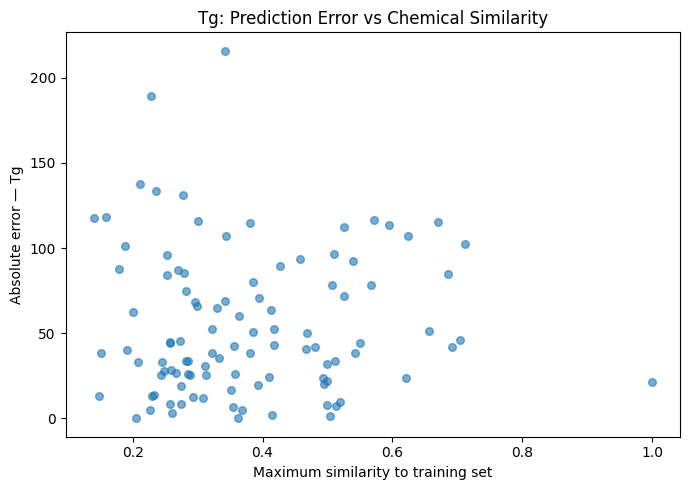

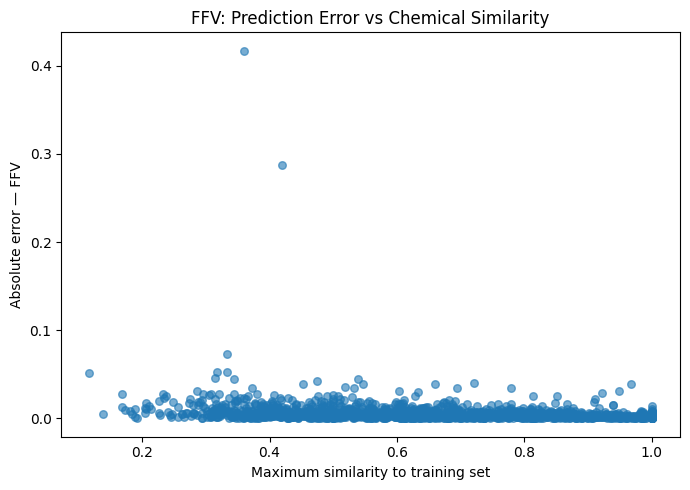

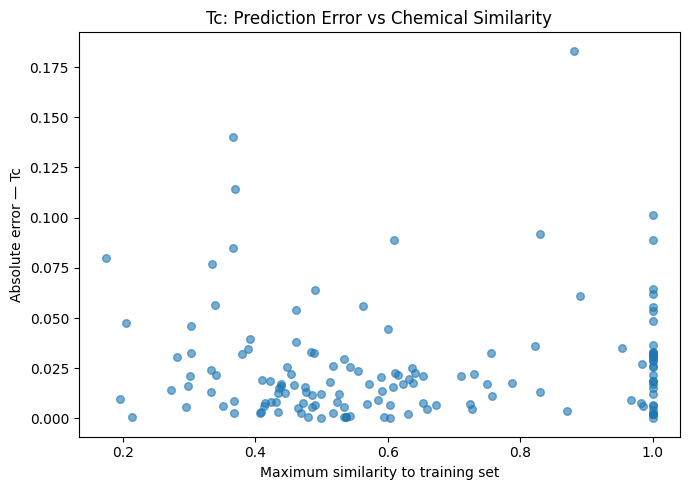

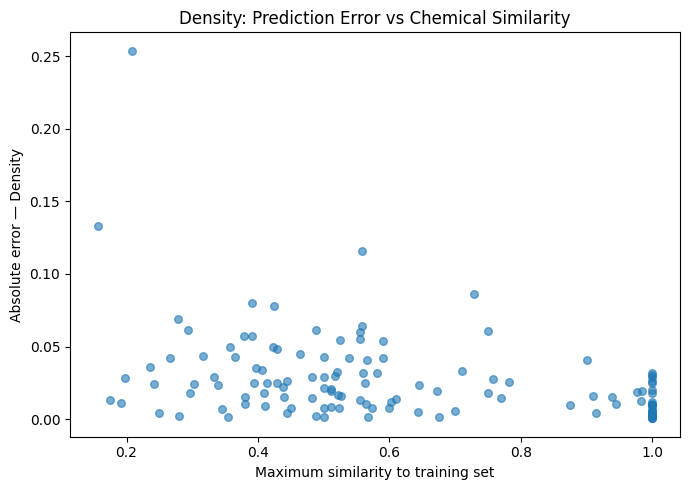

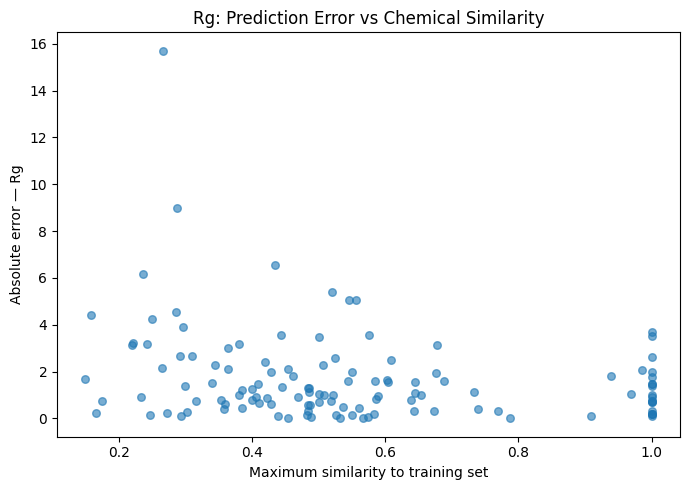

In [18]:
import matplotlib.pyplot as plt

for target, table in (
    chemistry_aware_tables.items()
):

    plt.figure(
        figsize=(7, 5)
    )

    plt.scatter(
        table[
            "max_train_similarity"
        ],
        table[
            "Absolute_Error"
        ],
        alpha=0.6,
        s=30
    )

    plt.xlabel(
        "Maximum similarity to training set"
    )

    plt.ylabel(
        f"Absolute error — {target}"
    )

    plt.title(
        f"{target}: Prediction Error vs Chemical Similarity"
    )

    plt.tight_layout()
    plt.show()

In [19]:
regime_counts = (
    pd.concat(
        [
            table[
                "Similarity_Regime"
            ]
            .value_counts(
                sort=False
            )
            .rename(target)

            for target, table
            in chemistry_aware_tables.items()
        ],
        axis=1
    )
    .fillna(0)
    .astype(int)
)

print(
    "HOLDOUT COUNTS BY CHEMICAL-NOVELTY REGIME"
)
print("=" * 90)

display(
    regime_counts
)

HOLDOUT COUNTS BY CHEMICAL-NOVELTY REGIME


,Tg,FFV,Tc,Density,Rg
Similarity_Regime,,,,,
High novelty (<0.4),65,200,25,28,34
Moderate novelty (0.4-0.6),29,390,53,47,50
Familiar (0.6-0.8),8,455,25,15,16
Highly familiar (>=0.8),1,361,45,33,23


## 15. Magnitude of the Chemical-Novelty Penalty

Correlation coefficients establish whether prediction error tends to vary with chemical similarity, but they do not directly quantify the magnitude of performance degradation.

For each property, the mean normalized absolute error in the high-novelty region is compared with that of chemically familiar polymers.

The generalization penalty is defined as:

$$
G =
\frac{\overline{\mathrm{NAE}}_{\mathrm{high\ novelty}}}
{\overline{\mathrm{NAE}}_{\mathrm{familiar}}}
$$

where the familiar reference combines polymers with maximum training similarity of at least 0.6.

A value greater than 1 indicates larger prediction errors for chemically novel polymers.

Results are interpreted cautiously when either comparison group contains few observations.

In [20]:
# ============================================================
# Quantify high-novelty generalization penalty
# ============================================================

generalization_penalty_rows = []

for target, table in chemistry_aware_tables.items():

    novel = table[
        table["max_train_similarity"] < 0.4
    ]

    familiar = table[
        table["max_train_similarity"] >= 0.6
    ]

    novel_mean = (
        novel["Normalized_Absolute_Error"].mean()
    )

    familiar_mean = (
        familiar["Normalized_Absolute_Error"].mean()
    )

    penalty_ratio = (
        novel_mean / familiar_mean
        if familiar_mean > 0
        else np.nan
    )

    generalization_penalty_rows.append({
        "Target":
            target,

        "Novel_n":
            len(novel),

        "Familiar_n":
            len(familiar),

        "Novel_Mean_NAE":
            novel_mean,

        "Familiar_Mean_NAE":
            familiar_mean,

        "Novelty_Penalty_Ratio":
            penalty_ratio
    })


generalization_penalty = pd.DataFrame(
    generalization_penalty_rows
)

print("CHEMICAL-NOVELTY GENERALIZATION PENALTY")
print("=" * 100)

display(
    generalization_penalty.round(4)
)

CHEMICAL-NOVELTY GENERALIZATION PENALTY


,Target,Novel_n,Familiar_n,Novel_Mean_NAE,Familiar_Mean_NAE,Novelty_Penalty_Ratio
0,Tg,65,9,0.4886,0.5920,0.8253
1,FFV,200,816,0.4220,0.1584,2.6647
2,Tc,25,70,0.4269,0.3066,1.3921
3,Density,28,48,0.2929,0.1095,2.6750
4,Rg,34,39,0.5671,0.2696,2.1033


## 16. Chemical Novelty and Property Extremeness

Chemical novelty and property-value extremeness may be correlated.

For example, a polymer may be difficult to predict not only because its molecular structure is unfamiliar, but also because its measured property lies near the edge of the training response distribution.

To examine this potential confounding effect, each holdout observation is assigned a standardized property extremeness:

$$
E_i =
\left|
\frac{y_i-\mu_{\mathrm{train}}}
{\sigma_{\mathrm{train}}}
\right|
$$

where $\mu_{\mathrm{train}}$ and $\sigma_{\mathrm{train}}$ are calculated exclusively from the corresponding frozen training partition.

Large values indicate observations located far from the central training-property range.

This analysis is diagnostic and does not alter the frozen models.

In [21]:
# ============================================================
# Property extremeness relative to training distribution
# ============================================================

extremeness_rows = []

for target, table in chemistry_aware_tables.items():

    split_target = frozen_splits[
        frozen_splits["Target"] == target
    ]

    train_idx = (
        split_target.loc[
            split_target["Partition"] == "train",
            "row_index"
        ]
        .astype(int)
        .to_numpy()
    )

    train_y = (
        metadata.loc[
            train_idx,
            target
        ]
        .to_numpy(dtype=float)
    )

    train_mean = np.mean(train_y)
    train_std = np.std(
        train_y,
        ddof=1
    )

    table["Property_Extremeness"] = np.abs(
        (
            table["Observed"]
            - train_mean
        )
        / train_std
    )

    rho, p_value = spearmanr(
        table["max_train_similarity"],
        table["Property_Extremeness"]
    )

    extremeness_rows.append({
        "Target":
            target,

        "Spearman_similarity_vs_extremeness":
            rho,

        "P_value":
            p_value,

        "Mean_extremeness":
            table[
                "Property_Extremeness"
            ].mean(),

        "Max_extremeness":
            table[
                "Property_Extremeness"
            ].max()
    })


extremeness_summary = pd.DataFrame(
    extremeness_rows
)

print(
    "CHEMICAL SIMILARITY VS PROPERTY EXTREMENESS"
)
print("=" * 100)

display(
    extremeness_summary.round(4)
)

CHEMICAL SIMILARITY VS PROPERTY EXTREMENESS


,Target,Spearman_similarity_vs_extremeness,P_value,Mean_extremeness,Max_extremeness
0,Tg,-0.1277,0.1985,0.7830,2.9369
1,FFV,-0.1089,0.0000,0.7054,13.8018
2,Tc,0.1273,0.1233,0.8482,2.5670
3,Density,-0.1915,0.0339,0.7490,5.1072
4,Rg,-0.0220,0.8094,0.8971,4.0053


In [22]:
extremeness_by_regime_rows = []

for target, table in chemistry_aware_tables.items():

    for regime in similarity_labels:

        group = table[
            table["Similarity_Regime"] == regime
        ]

        if len(group) == 0:
            continue

        extremeness_by_regime_rows.append({
            "Target":
                target,

            "Similarity_Regime":
                regime,

            "n":
                len(group),

            "Mean_Property_Extremeness":
                group[
                    "Property_Extremeness"
                ].mean(),

            "Median_Property_Extremeness":
                group[
                    "Property_Extremeness"
                ].median()
        })


extremeness_by_regime = pd.DataFrame(
    extremeness_by_regime_rows
)

print(
    "PROPERTY EXTREMENESS BY CHEMICAL-NOVELTY REGIME"
)
print("=" * 110)

display(
    extremeness_by_regime.round(4)
)

PROPERTY EXTREMENESS BY CHEMICAL-NOVELTY REGIME


,Target,Similarity_Regime,n,Mean_Property_Extremeness,Median_Property_Extremeness
0,Tg,High novelty (<0.4),65,0.8213,0.7598
1,Tg,Moderate novelty (0.4-0.6),29,0.7302,0.4608
2,Tg,Familiar (0.6-0.8),8,0.6550,0.7063
3,Tg,Highly familiar (>=0.8),1,0.8467,0.8467
4,FFV,High novelty (<0.4),200,0.8598,0.6534
5,FFV,Moderate novelty (0.4-0.6),390,0.7524,0.5707
6,FFV,Familiar (0.6-0.8),455,0.6849,0.5121
7,FFV,Highly familiar (>=0.8),361,0.5949,0.4699
8,Tc,High novelty (<0.4),25,0.7712,0.5467
9,Tc,Moderate novelty (0.4-0.6),53,0.8753,0.8419


## 17. Chemical Context of the Largest Holdout Errors

Notebook 03 identified a small number of observations that contributed disproportionately to total squared error.

The chemical-neighbourhood analysis now determines whether these catastrophic prediction failures tend to occur in structurally unfamiliar regions.

For each target, the ten largest absolute holdout errors are compared with their maximum training-set similarities.

In [23]:
# ============================================================
# Chemical novelty among worst prediction errors
# ============================================================

worst_error_novelty_rows = []

for target, table in chemistry_aware_tables.items():

    worst10 = (
        table
        .sort_values(
            "Absolute_Error",
            ascending=False
        )
        .head(10)
    )

    worst_error_novelty_rows.append({
        "Target":
            target,

        "Overall_Mean_Similarity":
            table[
                "max_train_similarity"
            ].mean(),

        "Worst10_Mean_Similarity":
            worst10[
                "max_train_similarity"
            ].mean(),

        "Worst10_Median_Similarity":
            worst10[
                "max_train_similarity"
            ].median(),

        "Worst10_HighNovelty_Count":
            int(
                (
                    worst10[
                        "max_train_similarity"
                    ] < 0.4
                ).sum()
            )
    })


worst_error_novelty = pd.DataFrame(
    worst_error_novelty_rows
)

print(
    "CHEMICAL NOVELTY OF THE TEN LARGEST ERRORS"
)
print("=" * 105)

display(
    worst_error_novelty.round(4)
)

CHEMICAL NOVELTY OF THE TEN LARGEST ERRORS


,Target,Overall_Mean_Similarity,Worst10_Mean_Similarity,Worst10_Median_Similarity,Worst10_HighNovelty_Count
0,Tg,0.3787,0.3136,0.2568,8
1,FFV,0.6413,0.3554,0.3389,7
2,Tc,0.6385,0.5933,0.4896,5
3,Density,0.6093,0.4088,0.4082,5
4,Rg,0.5542,0.3541,0.2869,6


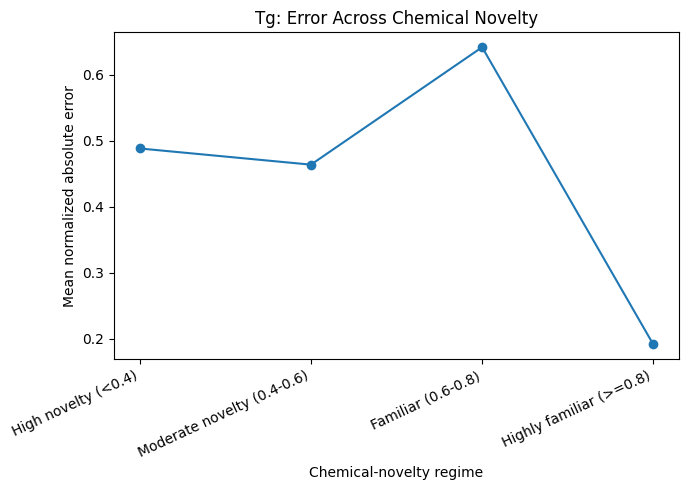

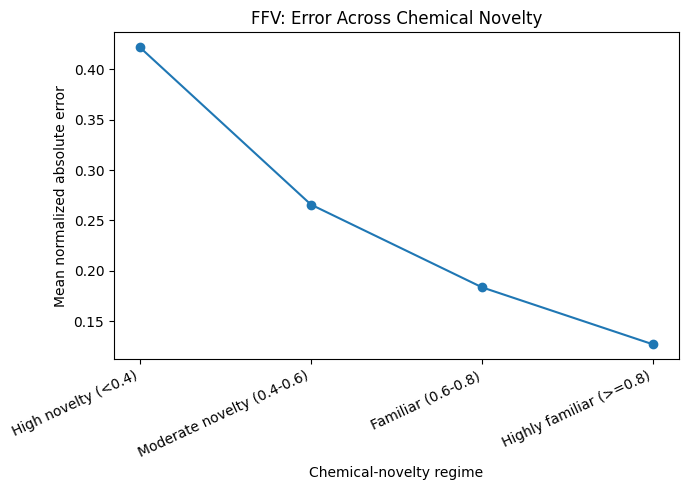

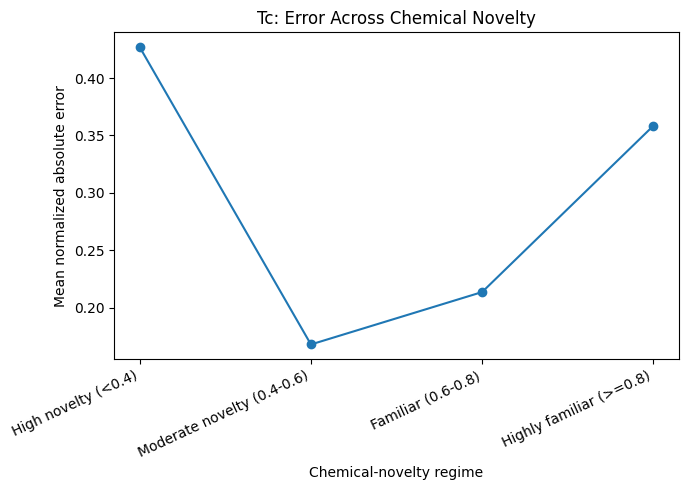

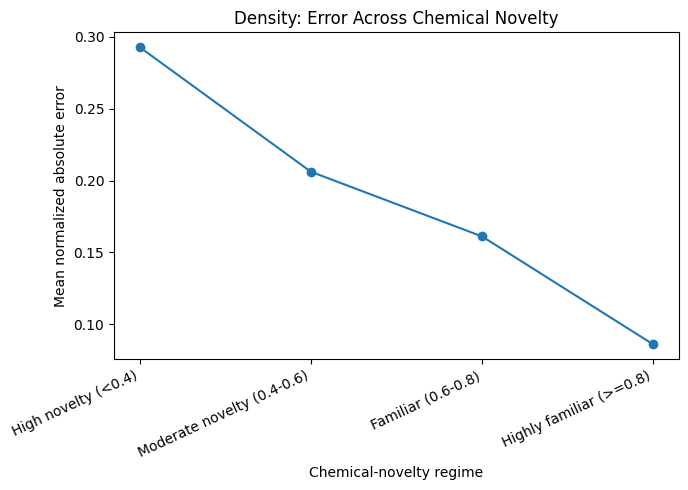

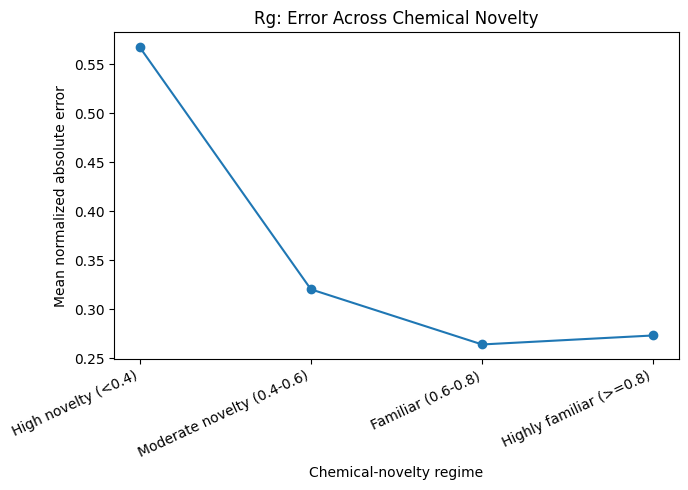

In [24]:
# ============================================================
# Normalized error across chemical novelty regimes
# ============================================================

for target in target_columns:

    subset = normalized_error_summary[
        normalized_error_summary["Target"]
        == target
    ].copy()

    subset["Similarity_Regime"] = pd.Categorical(
        subset["Similarity_Regime"],
        categories=similarity_labels,
        ordered=True
    )

    subset = subset.sort_values(
        "Similarity_Regime"
    )

    plt.figure(
        figsize=(7, 5)
    )

    plt.plot(
        subset["Similarity_Regime"],
        subset["Mean_NAE"],
        marker="o"
    )

    plt.ylabel(
        "Mean normalized absolute error"
    )

    plt.xlabel(
        "Chemical-novelty regime"
    )

    plt.title(
        f"{target}: Error Across Chemical Novelty"
    )

    plt.xticks(
        rotation=25,
        ha="right"
    )

    plt.tight_layout()
    plt.show()

## 19. Independent Association of Chemical Novelty With Prediction Error

Chemical novelty and property-value extremeness are not completely independent.

For some targets, structurally unfamiliar polymers also tend to occupy more unusual regions of the property distribution.

To determine whether chemical similarity contains predictive information about model reliability beyond this response-space effect, a partial Spearman correlation is calculated between:

- maximum training-set similarity;
- normalized absolute prediction error;

while controlling for property extremeness.

The partial rank correlation is:

$$
r_{XY \cdot Z}
=
\frac{
r_{XY} - r_{XZ}r_{YZ}
}{
\sqrt{
(1-r_{XZ}^{2})
(1-r_{YZ}^{2})
}
}
$$

where:

- $X$ is maximum training similarity;
- $Y$ is normalized absolute error;
- $Z$ is property extremeness.

A negative partial correlation indicates that increasing chemical novelty remains associated with larger prediction errors even after accounting for how extreme the observed property value is.

In [25]:
# ============================================================
# Partial Spearman correlation:
# similarity vs normalized error controlling for extremeness
# ============================================================

from scipy.stats import spearmanr, t

partial_correlation_rows = []

for target, table in chemistry_aware_tables.items():

    x = table[
        "max_train_similarity"
    ].to_numpy()

    y = table[
        "Normalized_Absolute_Error"
    ].to_numpy()

    z = table[
        "Property_Extremeness"
    ].to_numpy()

    r_xy, _ = spearmanr(x, y)
    r_xz, _ = spearmanr(x, z)
    r_yz, _ = spearmanr(y, z)

    denominator = np.sqrt(
        (1 - r_xz**2)
        *
        (1 - r_yz**2)
    )

    if denominator > 0:

        partial_r = (
            r_xy
            - r_xz * r_yz
        ) / denominator

    else:
        partial_r = np.nan

    n = len(table)

    if (
        np.isfinite(partial_r)
        and abs(partial_r) < 1
        and n > 3
    ):

        t_stat = (
            partial_r
            * np.sqrt(
                (n - 3)
                /
                (1 - partial_r**2)
            )
        )

        p_value = (
            2
            * t.sf(
                abs(t_stat),
                df=n - 3
            )
        )

    else:
        p_value = np.nan

    partial_correlation_rows.append({
        "Target":
            target,

        "n":
            n,

        "Raw_Spearman_similarity_error":
            r_xy,

        "Spearman_similarity_extremeness":
            r_xz,

        "Spearman_extremeness_error":
            r_yz,

        "Partial_Spearman_similarity_error":
            partial_r,

        "Partial_P_value":
            p_value
    })


partial_correlation_summary = pd.DataFrame(
    partial_correlation_rows
)

print(
    "PARTIAL SPEARMAN: CHEMICAL SIMILARITY VS ERROR"
)
print(
    "CONTROLLING FOR PROPERTY EXTREMENESS"
)
print("=" * 115)

display(
    partial_correlation_summary.round(4)
)

PARTIAL SPEARMAN: CHEMICAL SIMILARITY VS ERROR
CONTROLLING FOR PROPERTY EXTREMENESS


,Target,n,Raw_Spearman_similarity_error,Spearman_similarity_extremeness,Spearman_extremeness_error,Partial_Spearman_similarity_error,Partial_P_value
0,Tg,103,0.0528,-0.1277,0.3570,0.1062,0.2879
1,FFV,1406,-0.3161,-0.1089,0.1699,-0.3038,0.0000
2,Tc,148,0.0521,0.1273,-0.0065,0.0533,0.5213
3,Density,123,-0.3654,-0.1915,0.1730,-0.3437,0.0001
4,Rg,123,-0.2006,-0.0220,0.1270,-0.1994,0.0276


## 20. Explicit Chemistry-Separated Stress Test

The preceding analyses quantified chemical novelty within the original frozen random holdout.

Although this establishes how prediction error varies with structural similarity, the original train/test partition was still generated randomly.

A stricter robustness experiment is therefore performed using a chemistry-separated split.

Polymers are grouped according to their radius-4 Morgan fingerprint representation. Entire structural groups are assigned to either training or test partitions so that closely related polymers are less likely to occur on both sides of the split.

The models, representations, and hyperparameters selected in Notebook 03 remain frozen.

No model-family selection or hyperparameter tuning is performed during this experiment.

The purpose is solely to compare:

$$
\text{random-split generalization}
$$

with

$$
\text{chemistry-separated generalization}.
$$

A successful chemistry-aware split must also demonstrate lower test-to-training structural similarity than the original random holdout.

In [32]:
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import MiniBatchKMeans
from sklearn.model_selection import GroupShuffleSplit

RANDOM_STATE = 42

# Reduce the 2048-dimensional binary Morgan space
# while preserving broad structural variation.
svd = TruncatedSVD(
    n_components=50,
    random_state=RANDOM_STATE
)

X_chemistry_latent = svd.fit_transform(
    X_morgan_binary
)

print("CHEMISTRY CLUSTERING SPACE")
print("=" * 70)

print(
    "Original fingerprint shape:",
    X_morgan_binary.shape
)

print(
    "Reduced chemistry shape:   ",
    X_chemistry_latent.shape
)

print(
    "Explained variance captured:",
    f"{svd.explained_variance_ratio_.sum():.3f}"
)

CHEMISTRY CLUSTERING SPACE
Original fingerprint shape: (7973, 2048)
Reduced chemistry shape:    (7973, 50)
Explained variance captured: 0.430


In [33]:
N_CHEMICAL_CLUSTERS = 30

chemical_cluster_model = MiniBatchKMeans(
    n_clusters=N_CHEMICAL_CLUSTERS,
    random_state=RANDOM_STATE,
    batch_size=512,
    n_init=10
)

chemical_cluster_labels = (
    chemical_cluster_model.fit_predict(
        X_chemistry_latent
    )
)

cluster_sizes = pd.Series(
    chemical_cluster_labels
).value_counts().sort_index()

print("CHEMICAL CLUSTERS")
print("=" * 70)

print(
    f"Number of clusters: {len(cluster_sizes)}"
)

print(
    f"Smallest cluster:   {cluster_sizes.min()}"
)

print(
    f"Median cluster:     {cluster_sizes.median():.1f}"
)

print(
    f"Largest cluster:    {cluster_sizes.max()}"
)

CHEMICAL CLUSTERS
Number of clusters: 30
Smallest cluster:   87
Median cluster:     227.5
Largest cluster:    582


In [34]:
chemistry_split_indices = {}

for target in target_columns:

    available_idx = np.flatnonzero(
        metadata[target].notna().to_numpy()
    )

    target_groups = (
        chemical_cluster_labels[
            available_idx
        ]
    )

    splitter = GroupShuffleSplit(
        n_splits=1,
        test_size=0.20,
        random_state=RANDOM_STATE
    )

    train_local, test_local = next(
        splitter.split(
            available_idx,
            groups=target_groups
        )
    )

    train_idx = available_idx[
        train_local
    ]

    test_idx = available_idx[
        test_local
    ]

    chemistry_split_indices[target] = {
        "train_idx": train_idx,
        "test_idx": test_idx
    }

    train_clusters = set(
        chemical_cluster_labels[
            train_idx
        ]
    )

    test_clusters = set(
        chemical_cluster_labels[
            test_idx
        ]
    )

    assert train_clusters.isdisjoint(
        test_clusters
    )

    print(
        f"{target:8s} | "
        f"train={len(train_idx):4d} | "
        f"test={len(test_idx):4d} | "
        f"train clusters={len(train_clusters):2d} | "
        f"test clusters={len(test_clusters):2d}"
    )

Tg       | train= 425 | test=  86 | train clusters=22 | test clusters= 6
FFV      | train=5975 | test=1055 | train clusters=24 | test clusters= 6
Tc       | train= 609 | test= 128 | train clusters=19 | test clusters= 5
Density  | train= 522 | test=  91 | train clusters=20 | test clusters= 5
Rg       | train= 523 | test=  91 | train clusters=20 | test clusters= 5


In [35]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import (
    ExtraTreesRegressor,
    HistGradientBoostingRegressor
)

chemistry_stress_models = {

    "Tg": {
        "representation": "Hybrid",
        "model": ExtraTreesRegressor(
            n_estimators=300,
            max_features=1.0,
            min_samples_leaf=4,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    },

    "FFV": {
        "representation": "Hybrid",
        "model": HistGradientBoostingRegressor(
            learning_rate=0.1,
            max_iter=250,
            max_leaf_nodes=31,
            l2_regularization=1.0,
            random_state=RANDOM_STATE
        )
    },

    "Tc": {
        "representation": "Hybrid",
        "model": HistGradientBoostingRegressor(
            learning_rate=0.1,
            max_iter=250,
            max_leaf_nodes=31,
            l2_regularization=1.0,
            random_state=RANDOM_STATE
        )
    },

    "Density": {
        "representation": "Interpretable",
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("model", Ridge(alpha=10.0))
        ])
    },

    "Rg": {
        "representation": "Morgan_r4",
        "model": HistGradientBoostingRegressor(
            learning_rate=0.05,
            max_iter=250,
            max_leaf_nodes=15,
            l2_regularization=1.0,
            random_state=RANDOM_STATE
        )
    }
}

In [36]:
representation_matrices = {
    "Interpretable": X_interpretable,
    "Morgan_r4": X_morgan,
    "Hybrid": X_hybrid
}

In [37]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

chemistry_stress_results = []
chemistry_stress_predictions = {}

for target, spec in (
    chemistry_stress_models.items()
):

    train_idx = (
        chemistry_split_indices[target][
            "train_idx"
        ]
    )

    test_idx = (
        chemistry_split_indices[target][
            "test_idx"
        ]
    )

    representation = spec[
        "representation"
    ]

    model = spec["model"]

    X_full = representation_matrices[
        representation
    ]

    X_train = X_full[
        train_idx
    ]

    X_test = X_full[
        test_idx
    ]

    y_train = (
        metadata.loc[
            train_idx,
            target
        ]
        .to_numpy(dtype=float)
    )

    y_test = (
        metadata.loc[
            test_idx,
            target
        ]
        .to_numpy(dtype=float)
    )

    model.fit(
        X_train,
        y_train
    )

    y_pred = model.predict(
        X_test
    )

    r2 = r2_score(
        y_test,
        y_pred
    )

    mae = mean_absolute_error(
        y_test,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            y_pred
        )
    )

    chemistry_stress_predictions[target] = {
        "test_idx": test_idx,
        "y_true": y_test,
        "y_pred": y_pred
    }

    chemistry_stress_results.append({
        "Target": target,
        "Representation": representation,
        "Train_n": len(train_idx),
        "Test_n": len(test_idx),
        "R2": r2,
        "MAE": mae,
        "RMSE": rmse
    })

    print(
        f"{target:8s} | "
        f"R²={r2:.4f} | "
        f"MAE={mae:.4f} | "
        f"RMSE={rmse:.4f}"
    )


chemistry_stress_results = pd.DataFrame(
    chemistry_stress_results
)

print(
    "\nCHEMISTRY-SEPARATED STRESS TEST"
)
print("=" * 100)

display(
    chemistry_stress_results.round(4)
)

Tg       | R²=0.6548 | MAE=49.1040 | RMSE=62.9744
FFV      | R²=0.7993 | MAE=0.0069 | RMSE=0.0094
Tc       | R²=0.3259 | MAE=0.0325 | RMSE=0.0404
Density  | R²=0.8741 | MAE=0.0233 | RMSE=0.0286
Rg       | R²=0.6468 | MAE=1.8476 | RMSE=2.4899

CHEMISTRY-SEPARATED STRESS TEST


,Target,Representation,Train_n,Test_n,R2,MAE,RMSE
0,Tg,Hybrid,425,86,0.6548,49.1040,62.9744
1,FFV,Hybrid,5975,1055,0.7993,0.0069,0.0094
2,Tc,Hybrid,609,128,0.3259,0.0325,0.0404
3,Density,Interpretable,522,91,0.8741,0.0233,0.0286
4,Rg,Morgan_r4,523,91,0.6468,1.8476,2.4899


In [38]:
chemistry_split_similarity_rows = []

for target in target_columns:

    train_idx = (
        chemistry_split_indices[target][
            "train_idx"
        ]
    )

    test_idx = (
        chemistry_split_indices[target][
            "test_idx"
        ]
    )

    train_fps = [
        rdkit_fingerprints[i]
        for i in train_idx
    ]

    max_sims = []

    for idx in test_idx:

        similarities = (
            DataStructs.BulkTanimotoSimilarity(
                rdkit_fingerprints[idx],
                train_fps
            )
        )

        max_sims.append(
            max(similarities)
        )

    chemistry_split_similarity_rows.append({
        "Target":
            target,

        "Chemistry_test_n":
            len(test_idx),

        "Chemistry_split_mean_maxsim":
            np.mean(max_sims),

        "Chemistry_split_median_maxsim":
            np.median(max_sims),

        "Chemistry_split_below_0_4_pct":
            100 * np.mean(
                np.asarray(max_sims) < 0.4
            )
    })


chemistry_split_similarity = pd.DataFrame(
    chemistry_split_similarity_rows
)

random_similarity_reference = (
    similarity_summary[
        [
            "Target",
            "Mean",
            "Median"
        ]
    ]
    .rename(
        columns={
            "Mean":
                "Random_mean_maxsim",
            "Median":
                "Random_median_maxsim"
        }
    )
)

split_similarity_comparison = (
    random_similarity_reference
    .merge(
        chemistry_split_similarity,
        on="Target"
    )
)

print(
    "RANDOM VS CHEMISTRY-SEPARATED "
    "HOLDOUT SIMILARITY"
)
print("=" * 110)

display(
    split_similarity_comparison.round(4)
)

RANDOM VS CHEMISTRY-SEPARATED HOLDOUT SIMILARITY


,Target,Random_mean_maxsim,Random_median_maxsim,Chemistry_test_n,Chemistry_split_mean_maxsim,Chemistry_split_median_maxsim,Chemistry_split_below_0_4_pct
0,Tg,0.3787,0.3438,86,0.3220,0.3125,79.0698
1,FFV,0.6413,0.6364,1055,0.4685,0.4510,35.0711
2,Tc,0.6385,0.5784,128,0.3716,0.3913,71.8750
3,Density,0.6093,0.5556,91,0.3556,0.3333,64.8352
4,Rg,0.5542,0.5000,91,0.3556,0.3333,64.8352


In [39]:
random_vs_chemistry = (
    final_holdout_results[
        [
            "Target",
            "Test_R2",
            "Test_MAE",
            "Test_RMSE"
        ]
    ]
    .rename(
        columns={
            "Test_R2":
                "Random_R2",

            "Test_MAE":
                "Random_MAE",

            "Test_RMSE":
                "Random_RMSE"
        }
    )
    .merge(
        chemistry_stress_results[
            [
                "Target",
                "R2",
                "MAE",
                "RMSE"
            ]
        ],
        on="Target"
    )
    .rename(
        columns={
            "R2":
                "Chemistry_R2",

            "MAE":
                "Chemistry_MAE",

            "RMSE":
                "Chemistry_RMSE"
        }
    )
)

random_vs_chemistry[
    "Delta_R2"
] = (
    random_vs_chemistry[
        "Chemistry_R2"
    ]
    -
    random_vs_chemistry[
        "Random_R2"
    ]
)

random_vs_chemistry[
    "RMSE_increase_pct"
] = (
    100
    * (
        random_vs_chemistry[
            "Chemistry_RMSE"
        ]
        -
        random_vs_chemistry[
            "Random_RMSE"
        ]
    )
    /
    random_vs_chemistry[
        "Random_RMSE"
    ]
)

print(
    "RANDOM VS CHEMISTRY-SEPARATED PERFORMANCE"
)
print("=" * 120)

display(
    random_vs_chemistry.round(4)
)

RANDOM VS CHEMISTRY-SEPARATED PERFORMANCE


,Target,Random_R2,Random_MAE,Random_RMSE,Chemistry_R2,Chemistry_MAE,Chemistry_RMSE,Delta_R2,RMSE_increase_pct
0,Tg,0.6077,54.7176,69.0041,0.6548,49.1040,62.9744,0.0472,-8.7382
1,FFV,0.7036,0.0067,0.0164,0.7993,0.0069,0.0094,0.0957,-42.9418
2,Tc,0.8246,0.0249,0.0371,0.3259,0.0325,0.0404,-0.4987,8.8034
3,Density,0.9201,0.0275,0.0413,0.8741,0.0233,0.0286,-0.0460,-30.9273
4,Rg,0.7026,1.6985,2.6170,0.6468,1.8476,2.4899,-0.0558,-4.8580


## 21. Response-Distribution Audit Across Evaluation Splits

The random holdout and chemistry-separated holdout contain different polymers.

Consequently, differences in predictive metrics may reflect both:

1. changes in chemical novelty; and
2. changes in the numerical distribution of the target property.

For example, a chemistry-separated test set may be structurally more difficult while containing fewer extreme property values than the original random holdout.

The target distributions of the two evaluation sets are therefore compared before interpreting performance differences.

This prevents changes in R², MAE, or RMSE from being attributed solely to chemical separation when the response distributions themselves have also changed.

In [40]:
# ============================================================
# Compare target distributions across random and chemistry splits
# ============================================================

split_distribution_rows = []

for target in target_columns:

    # Original random holdout indices
    random_test_idx = (
        frozen_splits.loc[
            (frozen_splits["Target"] == target)
            &
            (frozen_splits["Partition"] == "test"),
            "row_index"
        ]
        .astype(int)
        .to_numpy()
    )

    # Chemistry-separated test indices
    chemistry_test_idx = (
        chemistry_split_indices[target]["test_idx"]
    )

    for split_name, idx in [
        ("Random_holdout", random_test_idx),
        ("Chemistry_holdout", chemistry_test_idx)
    ]:

        values = (
            metadata.loc[
                idx,
                target
            ]
            .to_numpy(dtype=float)
        )

        split_distribution_rows.append({
            "Target": target,
            "Split": split_name,
            "n": len(values),
            "Mean": np.mean(values),
            "Std": np.std(values, ddof=1),
            "Min": np.min(values),
            "P10": np.quantile(values, 0.10),
            "Median": np.median(values),
            "P90": np.quantile(values, 0.90),
            "Max": np.max(values),
            "Range": np.max(values) - np.min(values)
        })


split_target_distributions = pd.DataFrame(
    split_distribution_rows
)

print("TARGET DISTRIBUTIONS ACROSS EVALUATION SPLITS")
print("=" * 115)

display(
    split_target_distributions.round(4)
)

TARGET DISTRIBUTIONS ACROSS EVALUATION SPLITS


,Target,Split,n,Mean,Std,Min,P10,Median,P90,Max,Range
0,Tg,Random_holdout,103,97.5146,110.7072,-81.3830,-29.3746,73.8326,244.9910,423.6342,505.0172
1,Tg,Chemistry_holdout,86,104.1860,107.8184,-71.6811,-22.9901,73.2021,241.5235,358.6673,430.3483
2,FFV,Random_holdout,1406,0.3672,0.0301,0.2787,0.3369,0.3643,0.4014,0.7741,0.4954
3,FFV,Chemistry_holdout,1055,0.3616,0.0209,0.2959,0.3379,0.3591,0.3866,0.4350,0.1391
4,Tc,Random_holdout,148,0.2554,0.0889,0.0690,0.1556,0.2380,0.3775,0.4870,0.4180
5,Tc,Chemistry_holdout,128,0.3418,0.0494,0.1650,0.2850,0.3452,0.4019,0.4533,0.2883
6,Density,Random_holdout,123,0.9844,0.1469,0.7571,0.8347,0.9465,1.1542,1.7323,0.9752
7,Density,Chemistry_holdout,91,0.8882,0.0809,0.7719,0.8017,0.8704,0.9566,1.2068,0.4348
8,Rg,Random_holdout,123,16.4580,4.8182,9.7284,11.3757,15.0640,22.5979,34.6729,24.9446
9,Rg,Chemistry_holdout,91,14.9389,4.2125,10.0182,11.3220,13.5455,20.3561,29.3968,19.3786


In [41]:
# ============================================================
# Scale-normalized comparison across evaluation splits
# ============================================================

normalized_split_rows = []

for target in target_columns:

    # Random holdout
    random_pred = holdout_predictions[target]

    random_y = random_pred["Observed"].to_numpy(dtype=float)
    random_abs_error = random_pred["Absolute_Error"].to_numpy(dtype=float)

    random_std = np.std(
        random_y,
        ddof=1
    )

    random_mae = np.mean(
        random_abs_error
    )

    random_rmse = np.sqrt(
        np.mean(
            (random_pred["Residual"].to_numpy(dtype=float)) ** 2
        )
    )

    # Chemistry-separated holdout
    chemistry_info = (
        chemistry_stress_predictions[target]
    )

    chemistry_y = chemistry_info["y_true"]
    chemistry_pred = chemistry_info["y_pred"]

    chemistry_residual = (
        chemistry_y - chemistry_pred
    )

    chemistry_std = np.std(
        chemistry_y,
        ddof=1
    )

    chemistry_mae = np.mean(
        np.abs(
            chemistry_residual
        )
    )

    chemistry_rmse = np.sqrt(
        np.mean(
            chemistry_residual ** 2
        )
    )

    normalized_split_rows.extend([
        {
            "Target": target,
            "Split": "Random_holdout",
            "Test_target_std": random_std,
            "Normalized_MAE": (
                random_mae / random_std
            ),
            "Normalized_RMSE": (
                random_rmse / random_std
            )
        },
        {
            "Target": target,
            "Split": "Chemistry_holdout",
            "Test_target_std": chemistry_std,
            "Normalized_MAE": (
                chemistry_mae / chemistry_std
            ),
            "Normalized_RMSE": (
                chemistry_rmse / chemistry_std
            )
        }
    ])


normalized_split_performance = pd.DataFrame(
    normalized_split_rows
)

print(
    "SCALE-NORMALIZED RANDOM VS "
    "CHEMISTRY-SEPARATED PERFORMANCE"
)
print("=" * 110)

display(
    normalized_split_performance.round(4)
)

SCALE-NORMALIZED RANDOM VS CHEMISTRY-SEPARATED PERFORMANCE


,Target,Split,Test_target_std,Normalized_MAE,Normalized_RMSE
0,Tg,Random_holdout,110.7072,0.4943,0.6233
1,Tg,Chemistry_holdout,107.8184,0.4554,0.5841
2,FFV,Random_holdout,0.0301,0.2207,0.5443
3,FFV,Chemistry_holdout,0.0209,0.3312,0.4478
4,Tc,Random_holdout,0.0889,0.2799,0.4174
5,Tc,Chemistry_holdout,0.0494,0.6587,0.8178
6,Density,Random_holdout,0.1469,0.1873,0.2815
7,Density,Chemistry_holdout,0.0809,0.2881,0.3529
8,Rg,Random_holdout,4.8182,0.3525,0.5431
9,Rg,Chemistry_holdout,4.2125,0.4386,0.5911


## 22. Bootstrap Uncertainty of Evaluation Metrics

The random and chemistry-separated holdouts contain finite and unequal numbers of polymers.

Observed differences in performance may therefore partly reflect sampling variability.

Bootstrap resampling is used to estimate 95% confidence intervals for R², normalized MAE, and normalized RMSE within each evaluation set.

For each target and evaluation split, holdout observations are resampled with replacement 2,000 times.

No models are retrained during bootstrapping. The procedure quantifies uncertainty in the already-frozen predictions rather than introducing another model-selection stage.

Because the random and chemistry-separated splits contain different polymers and, for some properties, different response distributions, the resulting intervals are interpreted as uncertainty around each evaluation condition rather than as a paired statistical test.

In [42]:
# ============================================================
# Bootstrap confidence intervals for random and
# chemistry-separated evaluation metrics
# ============================================================

BOOTSTRAP_ITERATIONS = 2000
BOOTSTRAP_RANDOM_STATE = 42

rng = np.random.default_rng(
    BOOTSTRAP_RANDOM_STATE
)

bootstrap_rows = []

def bootstrap_metrics(
    y_true,
    y_pred,
    n_boot=2000
):

    y_true = np.asarray(
        y_true,
        dtype=float
    )

    y_pred = np.asarray(
        y_pred,
        dtype=float
    )

    n = len(y_true)

    r2_values = []
    nmae_values = []
    nrmse_values = []

    for _ in range(n_boot):

        idx = rng.integers(
            0,
            n,
            size=n
        )

        yt = y_true[idx]
        yp = y_pred[idx]

        test_std = np.std(
            yt,
            ddof=1
        )

        if (
            test_std == 0
            or len(np.unique(yt)) < 2
        ):
            continue

        residual = yt - yp

        r2_values.append(
            r2_score(
                yt,
                yp
            )
        )

        nmae_values.append(
            np.mean(
                np.abs(residual)
            )
            / test_std
        )

        nrmse_values.append(
            np.sqrt(
                np.mean(
                    residual ** 2
                )
            )
            / test_std
        )

    return {
        "R2_low":
            np.percentile(
                r2_values,
                2.5
            ),

        "R2_high":
            np.percentile(
                r2_values,
                97.5
            ),

        "NMAE_low":
            np.percentile(
                nmae_values,
                2.5
            ),

        "NMAE_high":
            np.percentile(
                nmae_values,
                97.5
            ),

        "NRMSE_low":
            np.percentile(
                nrmse_values,
                2.5
            ),

        "NRMSE_high":
            np.percentile(
                nrmse_values,
                97.5
            )
    }

In [43]:
for target in target_columns:

    # --------------------------------------------
    # Random holdout
    # --------------------------------------------

    random_table = (
        holdout_predictions[target]
    )

    random_ci = bootstrap_metrics(
        random_table[
            "Observed"
        ].to_numpy(),

        random_table[
            "Predicted"
        ].to_numpy(),

        n_boot=BOOTSTRAP_ITERATIONS
    )

    bootstrap_rows.append({
        "Target":
            target,

        "Split":
            "Random_holdout",

        **random_ci
    })


    # --------------------------------------------
    # Chemistry-separated holdout
    # --------------------------------------------

    chemistry_info = (
        chemistry_stress_predictions[
            target
        ]
    )

    chemistry_ci = bootstrap_metrics(
        chemistry_info[
            "y_true"
        ],

        chemistry_info[
            "y_pred"
        ],

        n_boot=BOOTSTRAP_ITERATIONS
    )

    bootstrap_rows.append({
        "Target":
            target,

        "Split":
            "Chemistry_holdout",

        **chemistry_ci
    })


bootstrap_metric_intervals = (
    pd.DataFrame(
        bootstrap_rows
    )
)


print(
    "BOOTSTRAP 95% CONFIDENCE INTERVALS"
)
print("=" * 120)

display(
    bootstrap_metric_intervals.round(4)
)

BOOTSTRAP 95% CONFIDENCE INTERVALS


,Target,Split,R2_low,R2_high,NMAE_low,NMAE_high,NRMSE_low,NRMSE_high
0,Tg,Random_holdout,0.4369,0.7172,0.4202,0.5941,0.5292,0.7467
1,Tg,Chemistry_holdout,0.5087,0.7549,0.3897,0.5330,0.4922,0.6969
2,FFV,Random_holdout,0.5020,0.8907,0.2071,0.2376,0.3305,0.7055
3,FFV,Chemistry_holdout,0.7709,0.8227,0.3123,0.3528,0.4209,0.4784
4,Tc,Random_holdout,0.7361,0.8911,0.2307,0.3391,0.3289,0.5119
5,Tc,Chemistry_holdout,0.0775,0.4930,0.5678,0.7845,0.7093,0.9567
6,Density,Random_holdout,0.8935,0.9444,0.1588,0.2359,0.2348,0.3250
7,Density,Chemistry_holdout,0.7675,0.9206,0.2320,0.3961,0.2802,0.4796
8,Rg,Random_holdout,0.5743,0.8198,0.3032,0.4137,0.4228,0.6498
9,Rg,Chemistry_holdout,0.5215,0.7244,0.3770,0.5307,0.5221,0.6880


In [44]:
bootstrap_summary_rows = []

for target in target_columns:

    for split_name in [
        "Random_holdout",
        "Chemistry_holdout"
    ]:

        if split_name == "Random_holdout":

            table = holdout_predictions[
                target
            ]

            y_true = table[
                "Observed"
            ].to_numpy()

            y_pred = table[
                "Predicted"
            ].to_numpy()

        else:

            info = (
                chemistry_stress_predictions[
                    target
                ]
            )

            y_true = info[
                "y_true"
            ]

            y_pred = info[
                "y_pred"
            ]

        residual = (
            y_true - y_pred
        )

        test_std = np.std(
            y_true,
            ddof=1
        )

        r2 = r2_score(
            y_true,
            y_pred
        )

        nmae = (
            np.mean(
                np.abs(residual)
            )
            / test_std
        )

        nrmse = (
            np.sqrt(
                np.mean(
                    residual ** 2
                )
            )
            / test_std
        )

        ci_row = (
            bootstrap_metric_intervals.loc[
                (
                    bootstrap_metric_intervals[
                        "Target"
                    ] == target
                )
                &
                (
                    bootstrap_metric_intervals[
                        "Split"
                    ] == split_name
                )
            ]
            .iloc[0]
        )

        bootstrap_summary_rows.append({
            "Target":
                target,

            "Split":
                split_name,

            "R2":
                r2,

            "R2_95CI":
                (
                    f"[{ci_row['R2_low']:.3f}, "
                    f"{ci_row['R2_high']:.3f}]"
                ),

            "Normalized_MAE":
                nmae,

            "NMAE_95CI":
                (
                    f"[{ci_row['NMAE_low']:.3f}, "
                    f"{ci_row['NMAE_high']:.3f}]"
                ),

            "Normalized_RMSE":
                nrmse,

            "NRMSE_95CI":
                (
                    f"[{ci_row['NRMSE_low']:.3f}, "
                    f"{ci_row['NRMSE_high']:.3f}]"
                )
        })


bootstrap_performance_summary = (
    pd.DataFrame(
        bootstrap_summary_rows
    )
)

print(
    "FINAL RANDOM VS CHEMISTRY-AWARE "
    "PERFORMANCE WITH UNCERTAINTY"
)
print("=" * 120)

display(
    bootstrap_performance_summary
)

FINAL RANDOM VS CHEMISTRY-AWARE PERFORMANCE WITH UNCERTAINTY


,Target,Split,R2,R2_95CI,Normalized_MAE,NMAE_95CI,Normalized_RMSE,NRMSE_95CI
0,Tg,Random_holdout,0.607684,"[0.437, 0.717]",0.494255,"[0.420, 0.594]",0.623303,"[0.529, 0.747]"
1,Tg,Chemistry_holdout,0.654838,"[0.509, 0.755]",0.455433,"[0.390, 0.533]",0.584079,"[0.492, 0.697]"
2,FFV,Random_holdout,0.703561,"[0.502, 0.891]",0.220736,"[0.207, 0.238]",0.544268,"[0.330, 0.705]"
3,FFV,Chemistry_holdout,0.799291,"[0.771, 0.823]",0.331240,"[0.312, 0.353]",0.447793,"[0.421, 0.478]"
4,Tc,Random_holdout,0.824556,"[0.736, 0.891]",0.279872,"[0.231, 0.339]",0.417443,"[0.329, 0.512]"
5,Tc,Chemistry_holdout,0.325890,"[0.078, 0.493]",0.658674,"[0.568, 0.784]",0.817828,"[0.709, 0.957]"
6,Density,Random_holdout,0.920107,"[0.894, 0.944]",0.187319,"[0.159, 0.236]",0.281502,"[0.235, 0.325]"
7,Density,Chemistry_holdout,0.874110,"[0.767, 0.921]",0.288147,"[0.232, 0.396]",0.352855,"[0.280, 0.480]"
8,Rg,Random_holdout,0.702570,"[0.574, 0.820]",0.352527,"[0.303, 0.414]",0.543150,"[0.423, 0.650]"
9,Rg,Chemistry_holdout,0.646771,"[0.521, 0.724]",0.438585,"[0.377, 0.531]",0.591056,"[0.522, 0.688]"


## 23. Notebook 04 Conclusions

Notebook 04 evaluated whether the predictive performance established in Notebook 03 remains reliable as polymers move away from the chemistry represented in the training data.

Two complementary chemistry-aware evaluations were performed.

First, the original frozen Notebook 03 holdout was retained and each test polymer was characterized according to its structural similarity to the corresponding target-specific training set.

Second, an explicit chemistry-separated stress test was constructed by grouping polymers in a reduced radius-4 Morgan fingerprint space and assigning entire structural clusters to either training or test partitions.

The Notebook 03 model families, representations, and hyperparameters remained frozen throughout the stress test. No additional model selection or hyperparameter optimization was performed.

### Chemical support within the original holdout

The conventional random holdout contained substantial structural novelty.

Median maximum training-set similarity varied strongly by property:

- Tg: approximately 0.34
- FFV: approximately 0.64
- Tc: approximately 0.58
- Density: approximately 0.56
- Rg: approximately 0.50

Tg was dominated by structurally distant polymers, whereas FFV contained both highly familiar and highly novel chemistry.

This allowed prediction reliability to be analysed continuously as a function of chemical support without modifying the original test set.

### Error–novelty relationships

Increasing chemical familiarity was significantly associated with decreasing absolute prediction error for:

- FFV: Spearman rho approximately −0.316
- Density: Spearman rho approximately −0.365
- Rg: Spearman rho approximately −0.201

Tg and Tc showed no meaningful monotonic relationship between nearest-training similarity and absolute error.

The importance of chemical similarity as a reliability indicator is therefore property dependent rather than universal.

### Magnitude of the novelty penalty

Comparing highly novel polymers with polymers having maximum training similarity of at least 0.6 showed substantial increases in normalized absolute error:

- FFV: approximately 2.66-fold
- Density: approximately 2.68-fold
- Rg: approximately 2.10-fold
- Tc: approximately 1.39-fold

The corresponding Tg ratio was not interpreted as a reliable generalization measure because the familiar comparison group contained very few observations.

### Chemical novelty and catastrophic errors

The largest prediction failures identified in Notebook 03 occurred disproportionately in chemically sparse regions.

For all five targets, the ten largest holdout errors had lower average maximum training similarity than the complete holdout population.

The effect was particularly strong for FFV, where the average maximum similarity decreased from approximately 0.64 across the complete holdout to approximately 0.36 among the ten largest errors.

Thus, chemical support helps explain part of the error-concentration behaviour observed in Notebook 03.

### Controlling for property extremeness

Some chemically novel polymers also occupied more extreme regions of the target-property distribution.

However, controlling for property extremeness using partial rank correlation did not remove the similarity–error relationship for FFV, Density, or Rg.

Partial Spearman correlations remained approximately:

- FFV: −0.304
- Density: −0.344
- Rg: −0.199

Chemical novelty therefore contributes information about predictive reliability beyond response-value extremeness alone.

### Explicit chemistry-separated stress test

A stricter structural generalization test was generated using polymer clusters derived from a truncated radius-4 Morgan fingerprint space.

The resulting test sets were substantially more chemically distant from their training sets than the original random holdouts.

Mean maximum training similarity decreased for every target, including:

- FFV: approximately 0.64 to 0.47
- Tc: approximately 0.64 to 0.37
- Density: approximately 0.61 to 0.37
- Rg: approximately 0.55 to 0.36

The majority of the chemistry-separated Tc, Density, and Rg test polymers had maximum training similarity below 0.4.

### Property-specific stress-test behaviour

Tc showed the strongest chemistry-separated failure.

Its holdout R² decreased from approximately 0.825 under random splitting to approximately 0.326 under chemical separation.

Normalized MAE increased from approximately 0.280 to 0.659, and bootstrap confidence intervals showed a clear separation between the two evaluation conditions.

This demonstrates substantial sensitivity of Tc prediction to chemical-domain shift.

Density remained strongly predictable under chemical separation but exhibited a moderate loss of reliability.

Its R² decreased from approximately 0.920 to 0.874, while normalized MAE increased from approximately 0.187 to 0.288.

Rg also showed moderate deterioration in typical prediction error, with normalized MAE increasing from approximately 0.352 to 0.439.

### Why FFV requires special interpretation

FFV illustrates why chemistry-aware evaluation cannot rely on R² alone.

Its chemistry-separated R² increased from approximately 0.704 to 0.799, yet normalized MAE worsened from approximately 0.221 to 0.331.

The response-distribution audit showed that the original random holdout contained extreme FFV values extending to approximately 0.77, whereas the chemistry-separated holdout extended only to approximately 0.44.

The chemistry-separated test therefore removed the extreme high-FFV tail responsible for several catastrophic Notebook 03 errors.

The higher R² does not indicate easier chemical extrapolation; it reflects, in part, a numerically less extreme response distribution.

### Tg remains comparatively insensitive to the chosen novelty definition

Tg did not show a consistent deterioration with decreasing Morgan-fingerprint similarity.

Its random and chemistry-separated bootstrap intervals overlapped strongly, and the chemistry-separated test produced slightly lower normalized errors.

This suggests that nearest-neighbour similarity in the chosen binary Morgan representation does not adequately explain Tg prediction difficulty.

Other structural, physical, or representation-dependent factors are likely important.

### Bootstrap uncertainty

Two thousand bootstrap resamples were used to quantify uncertainty in R², normalized MAE, and normalized RMSE for both evaluation conditions.

The strongest statistically distinguishable deterioration occurred for Tc.

Density and Rg showed more moderate changes with partially overlapping uncertainty intervals.

FFV demonstrated metric-dependent behaviour because of substantial differences in response distributions.

Tg showed no convincing chemistry-separated performance loss.

### Principal scientific conclusion

**Strong random-split predictive performance does not imply uniform generalization across polymer chemical space.**

Chemical novelty is a valuable indicator of reduced reliability for several polymer properties, but the magnitude and even direction of its effect depend on the target property, response distribution, and structural representation.

Chemistry-aware evaluation should therefore combine:

- structural support measures;
- conventional predictive metrics;
- scale-normalized errors;
- response-distribution auditing;
- and uncertainty estimates.

These findings motivate Notebook 05, which investigates whether information shared across related polymer properties can improve prediction and whether prediction-level uncertainty can provide a more direct measure of reliability than chemical similarity alone.

In [45]:
from pathlib import Path
import shutil
import json

notebook04_output_dir = Path(
    "polymer_atlas_notebook04_outputs"
)

# Remove premature export directory if it exists
if notebook04_output_dir.exists():
    shutil.rmtree(
        notebook04_output_dir
    )

notebook04_output_dir.mkdir(
    exist_ok=True
)

print(
    f"Clean output directory created: "
    f"{notebook04_output_dir}"
)

Clean output directory created: polymer_atlas_notebook04_outputs


In [46]:
summary_exports = {

    "chemical_similarity_summary.csv":
        similarity_summary,

    "similarity_error_correlations.csv":
        error_similarity_summary,

    "novelty_regime_performance.csv":
        regime_performance,

    "normalized_error_by_novelty.csv":
        normalized_error_summary,

    "novelty_generalization_penalty.csv":
        generalization_penalty,

    "similarity_property_extremeness.csv":
        extremeness_summary,

    "property_extremeness_by_regime.csv":
        extremeness_by_regime,

    "worst_error_chemical_novelty.csv":
        worst_error_novelty,

    "partial_similarity_error_correlations.csv":
        partial_correlation_summary,

    "novelty_regime_counts.csv":
        regime_counts.reset_index(),

    "chemistry_stress_test_results.csv":
        chemistry_stress_results,

    "random_vs_chemistry_similarity.csv":
        split_similarity_comparison,

    "random_vs_chemistry_performance.csv":
        random_vs_chemistry,

    "split_target_distributions.csv":
        split_target_distributions,

    "normalized_split_performance.csv":
        normalized_split_performance,

    "bootstrap_metric_intervals.csv":
        bootstrap_metric_intervals,

    "bootstrap_performance_summary.csv":
        bootstrap_performance_summary
}


for filename, dataframe in (
    summary_exports.items()
):

    dataframe.to_csv(
        notebook04_output_dir
        / filename,
        index=False
    )


print(
    f"{len(summary_exports)} "
    f"summary tables exported."
)

17 summary tables exported.


In [47]:
for target, table in (
    chemistry_aware_tables.items()
):

    table.to_csv(
        notebook04_output_dir
        / f"{target}_chemistry_aware_holdout.csv",
        index=False
    )

print(
    "Five chemistry-aware holdout "
    "tables exported."
)

Five chemistry-aware holdout tables exported.


In [48]:
chemistry_prediction_tables = {}

for target, info in (
    chemistry_stress_predictions.items()
):

    test_idx = np.asarray(
        info["test_idx"]
    )

    y_true = np.asarray(
        info["y_true"]
    )

    y_pred = np.asarray(
        info["y_pred"]
    )

    table = pd.DataFrame({
        "row_index":
            test_idx,

        "id":
            metadata.loc[
                test_idx,
                "id"
            ].to_numpy(),

        "SMILES":
            metadata.loc[
                test_idx,
                "SMILES"
            ].to_numpy(),

        "Observed":
            y_true,

        "Predicted":
            y_pred,

        "Residual":
            y_true - y_pred,

        "Absolute_Error":
            np.abs(
                y_true - y_pred
            ),

        "Chemical_Cluster":
            chemical_cluster_labels[
                test_idx
            ]
    })

    chemistry_prediction_tables[
        target
    ] = table

    table.to_csv(
        notebook04_output_dir
        / (
            f"{target}_chemistry_"
            f"stress_predictions.csv"
        ),
        index=False
    )


print(
    "Five chemistry-separated "
    "prediction tables exported."
)

Five chemistry-separated prediction tables exported.


In [49]:
chemistry_split_rows = []

for target in target_columns:

    train_idx = (
        chemistry_split_indices[
            target
        ]["train_idx"]
    )

    test_idx = (
        chemistry_split_indices[
            target
        ]["test_idx"]
    )

    for idx in train_idx:

        chemistry_split_rows.append({
            "Target":
                target,

            "row_index":
                int(idx),

            "Partition":
                "train",

            "Chemical_Cluster":
                int(
                    chemical_cluster_labels[
                        idx
                    ]
                )
        })

    for idx in test_idx:

        chemistry_split_rows.append({
            "Target":
                target,

            "row_index":
                int(idx),

            "Partition":
                "test",

            "Chemical_Cluster":
                int(
                    chemical_cluster_labels[
                        idx
                    ]
                )
        })


chemistry_split_table = pd.DataFrame(
    chemistry_split_rows
)

chemistry_split_table.to_csv(
    notebook04_output_dir
    / "chemistry_separated_target_splits.csv",
    index=False
)

print(
    "Chemistry-separated splits exported."
)

Chemistry-separated splits exported.


In [50]:
cluster_assignment_table = pd.DataFrame({
    "row_index":
        np.arange(
            len(metadata)
        ),

    "id":
        metadata["id"].to_numpy(),

    "Chemical_Cluster":
        chemical_cluster_labels
})


cluster_assignment_table.to_csv(
    notebook04_output_dir
    / "global_chemical_cluster_assignments.csv",
    index=False
)

print(
    "Global chemical-cluster assignments exported."
)

Global chemical-cluster assignments exported.


In [51]:
notebook04_config = {

    "random_state":
        42,

    "similarity_representation":
        "binary Morgan fingerprint",

    "source_fingerprint":
        "count Morgan r4 / 2048 from Notebook 02",

    "fingerprint_radius":
        4,

    "fingerprint_size":
        2048,

    "similarity_metric":
        "Tanimoto",

    "primary_support_metric":
        "maximum similarity to target-specific training set",

    "secondary_support_metric":
        "mean similarity to five nearest training polymers",

    "novelty_regimes": {
        "high_novelty":
            "max_similarity < 0.4",

        "moderate_novelty":
            "0.4 <= max_similarity < 0.6",

        "familiar":
            "0.6 <= max_similarity < 0.8",

        "highly_familiar":
            "max_similarity >= 0.8"
    },

    "chemistry_split": {
        "method":
            "TruncatedSVD + MiniBatchKMeans + GroupShuffleSplit",

        "svd_components":
            50,

        "chemical_clusters":
            30,

        "target_test_fraction":
            0.20,

        "whole_clusters_held_out":
            True
    },

    "stress_test_models":
        "Frozen Notebook 03 final model configurations",

    "stress_test_hyperparameter_tuning":
        False,

    "bootstrap_iterations":
        2000,

    "bootstrap_confidence_level":
        0.95,

    "principal_findings": {

        "Tc":
            "Strong chemistry-separated generalization loss.",

        "Density":
            "Moderate chemistry-related reliability degradation.",

        "Rg":
            "Moderate degradation in typical normalized error.",

        "FFV":
            (
                "Chemical novelty increases typical error, "
                "but random-vs-chemistry R2 comparison is "
                "confounded by major response-distribution "
                "differences and extreme random-holdout values."
            ),

        "Tg":
            (
                "No consistent reliability dependence on "
                "binary Morgan similarity."
            )
    }
}


with open(
    notebook04_output_dir
    / "notebook04_config.json",
    "w"
) as f:

    json.dump(
        notebook04_config,
        f,
        indent=2
    )


print(
    "Notebook 04 final configuration exported."
)

Notebook 04 final configuration exported.


In [52]:
archive_path = shutil.make_archive(
    "polymer_atlas_notebook04_outputs",
    "zip",
    root_dir=notebook04_output_dir
)

print(
    f"Notebook 04 archive created:\n"
    f"{archive_path}"
)

Notebook 04 archive created:
/content/polymer_atlas_notebook04_outputs.zip


In [53]:
print("NOTEBOOK 04 FINAL EXPORT AUDIT")
print("=" * 90)

exported_files = sorted(
    notebook04_output_dir.iterdir()
)

for path in exported_files:

    print(
        f"{path.name:55s} "
        f"{path.stat().st_size / 1024:.2f} KB"
    )

print(
    f"\nTotal exported files: "
    f"{len(exported_files)}"
)

print(
    "\nNotebook 04 scientific workflow complete."
)

NOTEBOOK 04 FINAL EXPORT AUDIT
Density_chemistry_aware_holdout.csv                     25.35 KB
Density_chemistry_stress_predictions.csv                10.90 KB
FFV_chemistry_aware_holdout.csv                         342.57 KB
FFV_chemistry_stress_predictions.csv                    170.45 KB
Rg_chemistry_aware_holdout.csv                          26.65 KB
Rg_chemistry_stress_predictions.csv                     11.38 KB
Tc_chemistry_aware_holdout.csv                          31.32 KB
Tc_chemistry_stress_predictions.csv                     15.60 KB
Tg_chemistry_aware_holdout.csv                          23.95 KB
Tg_chemistry_stress_predictions.csv                     12.60 KB
bootstrap_metric_intervals.csv                          1.39 KB
bootstrap_performance_summary.csv                       1.34 KB
chemical_similarity_summary.csv                         0.87 KB
chemistry_separated_target_splits.csv                   161.23 KB
chemistry_stress_test_results.csv                       0.4